Assignment 3 

t8220103 Βασίλειος Μυλωνάς 

Lets start by reading the csv and the json files from the github repo

In [1]:
import pandas as pd 


In [2]:
choices = pd.read_csv('https://raw.githubusercontent.com/jcpeterson/choices13k/refs/heads/main/c13k_selections.csv')

In [19]:
choices.head()

,Problem,Feedback,n,Block,Ha,pHa,La,Hb,pHb,Lb,LotShapeB,LotNumB,Amb,Corr,bRate,bRate_std
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843
3,4,True,18,3,37,0.05,8,87,0.25,-31,1,2,False,0,0.222222,0.387383
4,5,False,15,1,26,1.00,26,45,0.75,-36,2,5,False,0,0.586667,0.450185


In [3]:
problems = pd.read_json("https://raw.githubusercontent.com/jcpeterson/choices13k/refs/heads/main/c13k_problems.json", orient='index')

In [27]:
problems

,B,A
0,"[[0.9500000000000001, 21.0], [0.05, 23.0]]","[[0.9500000000000001, 26.0], [0.05, -1.0]]"
1,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6000000000000001, 14.0], [0.4, -18.0]]"
2,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"
3,"[[0.75, -31.0], [0.125, 86.5], [0.125, 87.5]]","[[0.05, 37.0], [0.9500000000000001, 8.0]]"
4,"[[0.25, -36.0], [0.375, 41.0], [0.1875, 43.0],...","[[1.0, 26.0], [0.0, 26.0]]"
...,...,...
14563,"[[0.199999999999999, 0.0], [0.8, 42.0]]","[[1.0, 30.0], [0.0, 30.0]]"
14564,"[[0.199999999999999, 7.0], [0.8, 18.0]]","[[0.5, 70.0], [0.5, -42.0]]"
14565,"[[0.6000000000000001, -34.0], [0.0125, 28.5], ...","[[0.4, 8.0], [0.6000000000000001, -17.0]]"
14566,"[[0.5, -12.0], [0.5, 45.0]]","[[0.5, 89.0], [0.5, -49.0]]"


Lets first merge the choices and problems into one dataframe like they did in the notebook example

In [4]:
c13k_w_gambles = choices.join(problems, how="left")

In [31]:
c13k_w_gambles

,Problem,Feedback,n,Block,Ha,pHa,La,Hb,pHb,Lb,LotShapeB,LotNumB,Amb,Corr,bRate,bRate_std,B,A
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460,"[[0.9500000000000001, 21.0], [0.05, 23.0]]","[[0.9500000000000001, 26.0], [0.05, -1.0]]"
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6000000000000001, 14.0], [0.4, -18.0]]"
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"
3,4,True,18,3,37,0.05,8,87,0.25,-31,1,2,False,0,0.222222,0.387383,"[[0.75, -31.0], [0.125, 86.5], [0.125, 87.5]]","[[0.05, 37.0], [0.9500000000000001, 8.0]]"
4,5,False,15,1,26,1.00,26,45,0.75,-36,2,5,False,0,0.586667,0.450185,"[[0.25, -36.0], [0.375, 41.0], [0.1875, 43.0],...","[[1.0, 26.0], [0.0, 26.0]]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14563,13002,True,15,3,30,1.00,30,42,0.80,0,0,1,True,0,0.367619,0.302731,"[[0.199999999999999, 0.0], [0.8, 42.0]]","[[1.0, 30.0], [0.0, 30.0]]"
14564,13003,True,15,5,70,0.50,-42,18,0.80,7,0,1,False,0,0.760000,0.364104,"[[0.199999999999999, 7.0], [0.8, 18.0]]","[[0.5, 70.0], [0.5, -42.0]]"
14565,13004,True,15,5,8,0.40,-17,31,0.40,-34,1,6,False,0,0.666667,0.367747,"[[0.6000000000000001, -34.0], [0.0125, 28.5], ...","[[0.4, 8.0], [0.6000000000000001, -17.0]]"
14566,13005,True,15,2,89,0.50,-49,45,0.50,-12,0,1,False,0,0.386667,0.381476,"[[0.5, -12.0], [0.5, 45.0]]","[[0.5, 89.0], [0.5, -49.0]]"


## MODEL 1: LINEAR REGRESSION

After reviewing the papers and trying to understand both the origin of the dataset and the available features, I understood that the problems are randomly sampled from a large space of gambles, which explains why different problems appear at different block numbers. Rather than attempting to directly reimplement the BEAST model, my approach is to engineer features that capture the key behavioral regularities identified in the paper. In particular, I focus on sensitivity to expected value and on four additional behavioral tendencies: pessimism (sensitivity to worst-case outcomes), a bias toward equal weighting of outcomes, sensitivity to the sign of payoffs, and a tendency to minimize the probability of immediate regret.

The papers i read are:

Erev, I., Ert, E., Plonsky, O., Cohen, D., & Cohen, O. (2017). From anomalies to forecasts: Toward a descriptive model of decisions under risk, under ambiguity, and from experience. Psychological Review, 124(4), 369–409. https://doi.org/10.1037/rev0000062

Peterson, J.C., Bourgin, D.D., Agrawal, M., Reichman, D., & Griffiths, T.L. (2021). Using large-scale experiments and machine learning to discover theories of human decision-making. Science, 372, 1209 - 1214.  https://api.semanticscholar.org/CorpusID:235396315

Bourgin, D.D., Peterson, J.C., Reichman, D., Griffiths, T.L., & Russell, S.J. (2019). Cognitive Model Priors for Predicting Human Decisions. International Conference on Machine Learning. https://api.semanticscholar.org/CorpusID:162184038


In [5]:
import numpy as np


In [6]:
feature_table = c13k_w_gambles.copy()

Firstly of course using the bRate_std column is practicly "cheating" because this is derived from the bRate metric.

The bRate column is what we want to predict

1) Sensitivity to expected value. The most important metric as per the authors of the papers is expected return. 

This can of course be derived from the data

Expected_value_of_a =  pha*Ha + (1-pha * la)

Also derived their difference

In [7]:
feature_table["EV_A"] = feature_table["pHa"] * feature_table["Ha"] + (1 - feature_table["pHa"]) * feature_table["La"]
feature_table["EV_B"] = feature_table["pHb"] * feature_table["Hb"] + (1 - feature_table["pHb"]) * feature_table["Lb"]
feature_table["EV_diff"] = feature_table["EV_B"] - feature_table["EV_A"]

2) Pessimism: The worst outcomes of each gamble

Worst_B = Worst outcome of the gamble (regardless of the probability)

Also derived their difference

In [8]:
def worst_from_dist(dist):
    return min(x for p, x in dist)

feature_table["Worst_A"] = feature_table[["Ha", "La"]].min(axis=1)
feature_table["Worst_B"] = feature_table["B"].apply(worst_from_dist)
feature_table["Worst_diff"] = feature_table["Worst_B"] - feature_table["Worst_A"]


3) Bias toward equal weighting of outcomes:

I calculated the expected value of the gambles if all outcomes had the same probabilities, as humans tend to weight probabilities equally.

This gives the model different prespectives of expected value and it chooses on its own how important they are.

In [9]:
def equal_weight_value(dist):
    return np.mean([x for p, x in dist])

feature_table["EW_A"] = feature_table["A"].apply(equal_weight_value)
feature_table["EW_B"] = feature_table["B"].apply(equal_weight_value)
feature_table["EW_diff"] = feature_table["EW_B"] - feature_table["EW_A"]


4) Minimizing the probability of immediate regret.

I derived these features:

Regret_A where its value is the difference between the best outcome of B minus the worst of A and comparing it to the best of gamble B.

Regret_B which is the same but choosing B and getting the worst possible outcome and comparing it to the best of gamble A.

In theory if regret_A or Regret_B are high then the choosing A or B has a risk of getting strong immediate regret.


In [10]:
# --- Regret features ---
feature_table["Regret_A"] = feature_table[["Hb", "Lb"]].max(axis=1) - feature_table["Worst_A"]
feature_table["Regret_B"] = feature_table[["Ha", "La"]].max(axis=1) - feature_table["Worst_B"]
feature_table["Regret_diff"] = feature_table["Regret_B"] - feature_table["Regret_A"]


5) Sensitivity to sign: There is no way to derive a feature that would help the model, without forcing behavior.
A feature of "loss aversion" or actually modifying the raw negative outcomes would prevent the model from independently learning whether and how strongly negative outcomes should be weighted relative to gains.


6) The amb and feedback columns are boolean, lets turn them numeric

In [11]:
feature_table["Amb"] = feature_table["Amb"].astype(int)
feature_table["Feedback"] = feature_table["Feedback"].astype(int)


7) As per the notebook example as well, there are some problems that one choice is completely better than the other (they have bRate_std = 0)

These are problems where one option is clearly better that the other

In [12]:
feature_table["A_dominates"] = (
    (feature_table["Ha"] >= feature_table["Hb"]) &
    (feature_table["La"] >= feature_table["Lb"])).astype(int)

feature_table["B_dominates"] = (
    (feature_table["Hb"] >= feature_table["Ha"]) &
    (feature_table["Lb"] >= feature_table["La"])).astype(int)


In [13]:
feature_table = feature_table.drop(columns=['A', 'B'])

## This is the final feature table with 28 features (30 - the bRate columns)

In [14]:
feature_table

,Problem,Feedback,n,Block,Ha,pHa,La,Hb,pHb,Lb,...,Worst_B,Worst_diff,EW_A,EW_B,EW_diff,Regret_A,Regret_B,Regret_diff,A_dominates,B_dominates
0,1,1,15,2,26,0.95,-1,23,0.05,21,...,21.0,22.0,12.5,22.000000,9.500000,24,5.0,-19.0,0,0
1,2,1,15,4,14,0.60,-18,8,0.25,-5,...,-5.0,13.0,-2.0,1.500000,3.500000,26,19.0,-7.0,0,0
2,3,1,17,4,2,0.50,0,1,1.00,1,...,1.0,1.0,1.0,1.000000,0.000000,1,1.0,0.0,0,0
3,4,1,18,3,37,0.05,8,87,0.25,-31,...,-31.0,-39.0,22.5,47.666667,25.166667,79,68.0,-11.0,0,0
4,5,0,15,1,26,1.00,26,45,0.75,-36,...,-36.0,-62.0,26.0,36.833333,10.833333,19,62.0,43.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14563,13002,1,15,3,30,1.00,30,42,0.80,0,...,0.0,-30.0,30.0,21.000000,-9.000000,12,30.0,18.0,0,0
14564,13003,1,15,5,70,0.50,-42,18,0.80,7,...,7.0,49.0,14.0,12.500000,-1.500000,60,63.0,3.0,0,0
14565,13004,1,15,5,8,0.40,-17,31,0.40,-34,...,-34.0,-17.0,-4.5,21.714286,26.214286,48,42.0,-6.0,0,0
14566,13005,1,15,2,89,0.50,-49,45,0.50,-12,...,-12.0,37.0,20.0,16.500000,-3.500000,94,101.0,7.0,0,0


The problem and n columns should not be features, as they dont offer any relevant information to the prediction of bRate. 

I dont have participants id's or the actual problems each participant viewed and as the example notebook said, there is a small subset with almost double participants due to Mechanical Turk errors.

I assume each problem was seen by the average n=16 participants and not use neither into any models (I did use them later and of course they did not offer anything)

The block column also offers minimal information, as the participants completed only 2 trials per problem not 5

In [15]:
feature_cols = [
    # 'Problem',
    'Feedback',
    # 'n',
    # 'Block',
    'Ha',
    'pHa',
    'La',
    'Hb',
    'pHb',
    'Lb',
    'LotShapeB',
    'LotNumB', 
    'Amb', 
    'Corr',
    'EV_A',
    'EV_B',
    'EV_diff',
    'EW_A',
    'EW_B',
    'EW_diff',
    'Worst_A',
    'Worst_B', 
    'Worst_diff',
    "Regret_A",
    "Regret_B",
    "Regret_diff",
    'A_dominates',
    'B_dominates',
]

X = feature_table[feature_cols]
y = feature_table["bRate"]


Full pipeline of how i worked:

The above is the feature table with all the derived features i could think of which may help me . It also contains the classic data from the problems and choices dataframe. What i did was: 

First i run a linear regression model, to get a baseline of how well the linear model can predict bRate

In [16]:
from sklearn.preprocessing import StandardScaler

Here is what features i choose to standardize or encode since we are talking about a linear model:

Features whose numerical scale is arbitrary (for example, values that depend on the size of the payoffs) were rescaled before fitting the linear model, while binary features and features where the actual size of the value is meaningful were left unchanged.

In [17]:
scale_cols = [
    "Ha", "La",
    "Hb", "Lb",
    "pHa", "pHb",
    "LotNumB",
    "EV_A", "EV_B", "EV_diff",
    "EW_A", "EW_B", "EW_diff",
]

In [18]:
# scale_cols = ["EV_diff",  "Worst_diff", 'EV_A','Ha', 'La', 'Hb', 'Lb', "Regret_A", "Regret_B"]

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[scale_cols] = scaler.fit_transform(X_scaled[scale_cols])

Encoding categorical columns https://www.geeksforgeeks.org/machine-learning/ml-one-hot-encoding/

In [19]:
X_scaled = pd.get_dummies(
    X_scaled,
    columns=["LotShapeB", "Corr"],
    drop_first=False,
    dtype=int
)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


In [21]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
y_pred = lr.predict(X_test)


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression MAE:  {mae:.4f}")
print(f"Linear Regression R2:   {r2:.4f}")
print(f"Linear Regression RMSE: {rmse:.4f}")


Linear Regression MAE:  0.1155
Linear Regression R2:   0.5777
Linear Regression RMSE: 0.1438


In [24]:
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold

scores = cross_validate(
    lr,
    X_scaled,
    y,
    scoring=['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error'],
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=1   
)
print('CV MAE', np.mean(-scores['test_neg_mean_absolute_error']))
print('CV R2', np.mean(scores['test_r2']))
print('CV RMSE', np.mean(-scores['test_neg_root_mean_squared_error']))

CV MAE 0.11312397925117093
CV R2 0.5976040289834955
CV RMSE 0.1406484651445285


### I will stop here since , as the papers have shown,  human choice behavior contains strong nonlinearities and interactions that linear models cannot capture. There is no reason to keep going with a linear model, it will not beat a tree model.

# Feature Evalutation

After creating all these metrics, i need to have a secure way of evaluating them. 

The first is a function which outputs the correlation between features, so that i know if i have features that are correlated -maybe they do not give any extra information to the models.

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_feature_correlation(df, features):
    corr = df[features].corr(method="spearman")
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Spearman Correlation Between Features")
    plt.show()


The second is a function that outputs the permutation importance, 

In [26]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import KFold
from sklearn.inspection import permutation_importance

def permutation_importance_cv(
    estimator, X, y, n_splits=5, n_repeats=20, random_state=42, scoring="neg_mean_absolute_error"
):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    fold_means = []
    fold_stds = []

    for train_idx, val_idx in kf.split(X):
        est = clone(estimator)

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = (y.iloc[train_idx], y.iloc[val_idx]) if hasattr(y, "iloc") else (y[train_idx], y[val_idx])

        est.fit(X_train, y_train)

        r = permutation_importance(
            est,
            X_val,
            y_val,
            scoring=scoring,
            n_repeats=n_repeats,
            random_state=random_state,
            n_jobs=-1
        )

        # r.importances shape: (n_features, n_repeats)
        fold_means.append(r.importances_mean)
        fold_stds.append(r.importances_std)

    fold_means = np.vstack(fold_means)
    fold_stds  = np.vstack(fold_stds)

    out = pd.DataFrame({
        "importance_mean": fold_means.mean(axis=0),
        "importance_std_across_folds": fold_means.std(axis=0),
        "perm_std_mean": fold_stds.mean(axis=0),
    }, index=X.columns).sort_values("importance_mean", ascending=False)

    return out


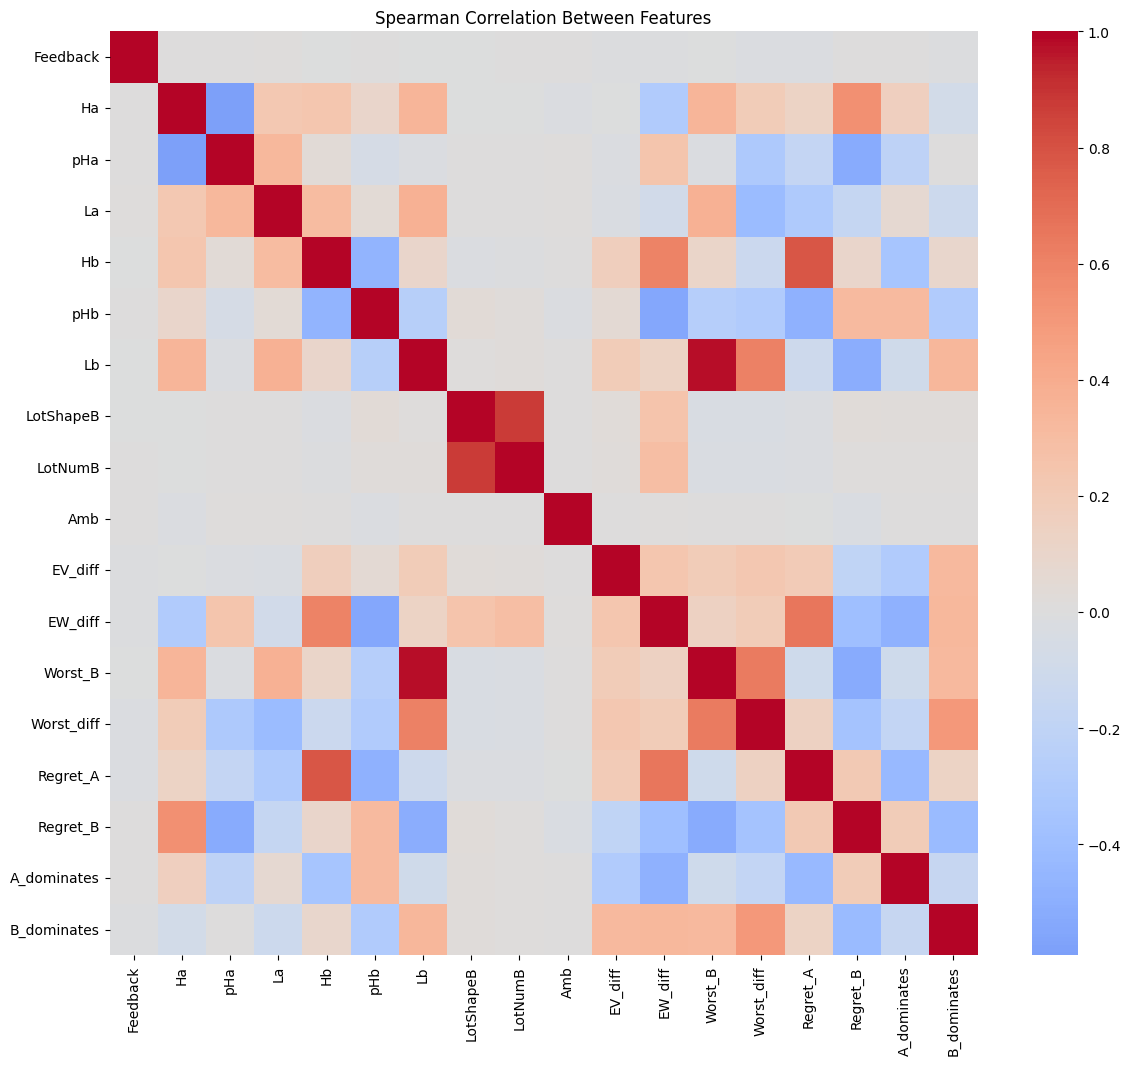

In [29]:
plot_feature_correlation(X, X.columns)

## XGBoost regression

Full pipeline:

I looked at the feature table and tried multiple variations of implemended features, running the two Xgboost models and using their mae score output as baseline and then evaluating the features on both the importance scores, the correlation table and the actual drop or increase of mae score. 

Since the goal of the assignment is to predict the bRate, my goal here is to just bring the mae score down as much as possible. This can lead to a bit of randomness in choosing what features i will include , as sometimes i cannot actually explain or understand why or how the mae score dropped. 

Some features can be correlated, some features can have really low importance score, but they did bring the mae score down just a little, so they will be kept. 

Using these scores as baseline might be wrong, but i do not have time to run optuna and permutation importance everytime i changed the feature table and they actually provide a good enough representation of mae score

The final feature table used is the one without the commented out columns- in this case: 19 Features

In [100]:
feature_cols = [
    # 'Problem',
    'Feedback',
    # 'n',
    # 'Block',
    'Ha',
    'pHa',
    'La',
    'Hb',
    'pHb',
    'Lb',
    'LotShapeB',
    'LotNumB', 
    'Amb', 
    # 'Corr',
    # 'EV_A',
    # 'EV_B',
    'EV_diff',
    # 'EW_A',
    # 'EW_B',
    'EW_diff',
    # 'Worst_A',
    'Worst_B', 
    'Worst_diff',
    "Regret_A",
    "Regret_B",
    # "Regret_diff",
    'A_dominates',
    'B_dominates',
]

X = feature_table[feature_cols]
y = feature_table["bRate"]


In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [102]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=4,          
    verbosity=1
)

xgb.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [103]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_xgb = xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)

print(f"XGB Test MAE:  {mae:.4f}")
print(f"XGB Test RMSE: {rmse:.4f}")
print(f"XGB Test R²:   {r2:.4f}")


XGB Test MAE:  0.0735
XGB Test RMSE: 0.0940
XGB Test R²:   0.8194


In [104]:
from sklearn.model_selection import cross_validate

scores = cross_validate(
    xgb,
    X,
    y,
    scoring=['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error'],
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=1   
)
print('CV MAE', np.mean(-scores['test_neg_mean_absolute_error']))
print('CV R2', np.mean(scores['test_r2']))
print('CV RMSE', np.mean(-scores['test_neg_root_mean_squared_error']))

CV MAE 0.07540850633149435
CV R2 0.8157480800691654
CV RMSE 0.09517569639661679


After some tries with optuna hyperparameterization i found that these parameters (or similar) generally lowers the mae

In [105]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [106]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    # objective="reg:logistic",
    # objective="reg:squarederror",
    objective="reg:squaredlogerror",
    # objective="reg:absoluteerror",
    # objective="reg:pseudohubererror",
    # objective="binary:logistic",
    # objective="binary:logitraw",
    random_state=42,
    n_jobs=4,          
    verbosity=1
)

xgb.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squaredlogerror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabet

In [107]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_xgb = xgb.predict(X_test)

## if logit_raw
# y_pred_xgb = 1 / (1 + np.exp(-y_pred_xgb))

mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)

print(f"XGB Test MAE:  {mae:.4f}")
print(f"XGB Test R²:   {r2:.4f}")
print(f"XGB Test RMSE: {rmse:.4f}")

XGB Test MAE:  0.0731
XGB Test R²:   0.8204
XGB Test RMSE: 0.0938


In [108]:
from sklearn.model_selection import cross_validate

scores = cross_validate(
    xgb,
    X,
    y,
    scoring=['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error'],
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=1   
)
print('CV MAE', np.mean(-scores['test_neg_mean_absolute_error']))
print('CV R2', np.mean(scores['test_r2']))
print('CV RMSE', np.mean(-scores['test_neg_root_mean_squared_error']))

CV MAE 0.07560524068828142
CV R2 0.8150655139885412
CV RMSE 0.0953498794727414


In [1084]:
permutation_importance_cv(xgb, X, y, n_splits=5)

,importance_mean,importance_std_across_folds,perm_std_mean
EV_diff,0.069678,0.001764,0.001686
La,0.013970,0.000674,0.000747
EW_diff,0.013915,0.001032,0.000599
Amb,0.010875,0.000828,0.000597
Regret_B,0.009909,0.000318,0.000459
Ha,0.008265,0.000593,0.000480
Regret_A,0.007330,0.000390,0.000387
Lb,0.006053,0.000621,0.000470
Hb,0.005582,0.000346,0.000477
pHb,0.004625,0.000558,0.000387


## Hyperparameter tuning with optuna on the XGBOOST model

In [96]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import KFold

In [97]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)


I am returning mae for quickness

Theoretically the lowest mae doesnt mean it is the lowest cv_mae, but i am doing it so that it can run quick and doesnt need to cross validate it each time

In [109]:
def objective(trial):
    # params = {
    #     "n_estimators": trial.suggest_int("n_estimators", 1000, 1200),
    #     "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
    #     "max_depth": trial.suggest_int("max_depth", 2, 10),
    #     "min_child_weight": trial.suggest_float("min_child_weight", 1e-2, 20.0, log=True),
    #     "subsample": trial.suggest_float("subsample", 0.6, 1.0),
    #     "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
    #     "gamma": trial.suggest_float("gamma", 0.0, 5.0),
    #     "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
    #     "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    # }
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 800, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.4),
        "max_depth": trial.suggest_int("max_depth", 4, 8),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-2, 20.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.8, 0.8),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.8, 0.8),
        # "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        # "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        # "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }
    

    model = XGBRegressor(
        **params,
        # objective="reg:squaredlogerror",
        objective="reg:logistic",
        random_state=42,
        n_jobs=1,         
        verbosity=0
    )

    model.fit(X_train, y_train)
    
    y_pred_xgb = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred_xgb)

    return mae


In [110]:
from optuna.samplers import TPESampler

sampler = TPESampler(seed=42)
study = optuna.create_study(direction="minimize", sampler=sampler)

study.optimize(objective, n_trials=300, n_jobs=-1, show_progress_bar=True, timeout = 600)

print("Best MAE:", study.best_value)
print("Best params:", study.best_params)


[I 2026-02-08 19:36:27,150] A new study created in memory with name: no-name-9d0b77e9-45f2-428f-a693-32d23163ca8c


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2026-02-08 19:36:32,030] Trial 7 finished with value: 0.08246042004596142 and parameters: {'n_estimators': 887, 'learning_rate': 0.357693336748157, 'max_depth': 5, 'min_child_weight': 0.0442270617485399, 'subsample': 0.8, 'colsample_bytree': 0.8}. Best is trial 7 with value: 0.08246042004596142.
[I 2026-02-08 19:36:32,339] Trial 2 finished with value: 0.0770504294357954 and parameters: {'n_estimators': 1220, 'learning_rate': 0.17667153575790173, 'max_depth': 4, 'min_child_weight': 0.055068744066764326, 'subsample': 0.8, 'colsample_bytree': 0.8}. Best is trial 2 with value: 0.0770504294357954.
[I 2026-02-08 19:36:34,453] Trial 1 finished with value: 0.0788450569124587 and parameters: {'n_estimators': 1143, 'learning_rate': 0.1848730033971855, 'max_depth': 5, 'min_child_weight': 0.10427356616501203, 'subsample': 0.8, 'colsample_bytree': 0.8}. Best is trial 2 with value: 0.0770504294357954.
[I 2026-02-08 19:36:35,033] Trial 0 finished with value: 0.07276288586348821 and parameters: {'n

In [112]:
best_params = study.best_params

best_xgb = XGBRegressor(
    **best_params,
    objective="reg:logistic",
    random_state=42,
    n_jobs=1,
    verbosity=0
)
best_xgb.fit(X_train, y_train)

y_pred = best_xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"XGB Test MAE:  {mae:.4f}")
print(f"XGB Test R2:   {r2:.4f}")
print(f"XGB Test RMSE: {rmse:.4f}")

XGB Test MAE:  0.0722
XGB Test R2:   0.8255
XGB Test RMSE: 0.0924


In [113]:
from sklearn.model_selection import cross_validate

scores = cross_validate(
    best_xgb,
    X,
    y,
    scoring=['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error'],
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=1   
)
print('CV MAE', np.mean(-scores['test_neg_mean_absolute_error']))
print('CV R2', np.mean(scores['test_r2']))
print('CV RMSE', np.mean(-scores['test_neg_root_mean_squared_error']))

CV MAE 0.07461695102488301
CV R2 0.8198282631372766
CV RMSE 0.09411708415800128


In [1098]:
permutation_importance_cv(best_xgb, X, y, n_splits=5)

,importance_mean,importance_std_across_folds,perm_std_mean
EV_diff,0.070590,0.001363,0.001688
La,0.013786,0.000549,0.000727
Amb,0.011033,0.000795,0.000586
EW_diff,0.010826,0.001127,0.000530
Regret_B,0.010349,0.000374,0.000481
Regret_A,0.008715,0.000533,0.000436
Ha,0.008160,0.000643,0.000462
Hb,0.005458,0.000466,0.000429
Lb,0.005326,0.000284,0.000460
pHb,0.004594,0.000549,0.000362


## Lets run a different model, where a more complete example is in the lectures, LightGBM

In [66]:
import lightgbm as lgb

lgb_reg = lgb.LGBMRegressor(force_col_wise=True)


In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [68]:
lgb_reg = lgb.LGBMRegressor(force_col_wise=True)
lgb_reg.fit(X_train, y_train)


[LightGBM] [Info] Total Bins 1629
[LightGBM] [Info] Number of data points in the train set: 11654, number of used features: 18
[LightGBM] [Info] Start training from score 0.518642


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [69]:
preds = lgb_reg.predict(X_test)

In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_lgb = lgb_reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
r2 = r2_score(y_test, y_pred_lgb)

print(f"XGB Test MAE:  {mae:.4f}")
print(f"XGB Test R2:   {r2:.4f}")
print(f"XGB Test RMSE: {rmse:.4f}")

XGB Test MAE:  0.0748
XGB Test R2:   0.8131
XGB Test RMSE: 0.0957


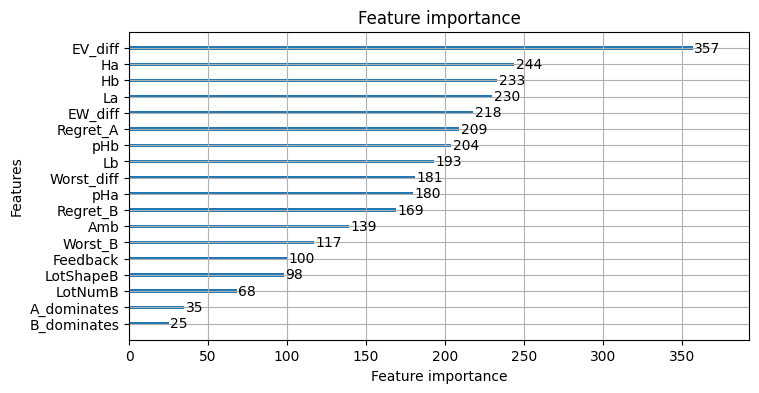

In [1104]:
lgb_reg = lgb.LGBMRegressor(force_col_wise=True)
lgb_reg.fit(X_train, y_train)
_ = lgb.plot_importance(lgb_reg, figsize=(8, 4))

## Light gbm with optuna hyperparameter optimization

In [1105]:
from sklearn.model_selection import train_test_split

X_train_rf, X_test_rf, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


This is similar to the example in the lectures, but with different parameters of course and also using l1 (mean absolute error) instead of l2 (mean squared error)

These parameters where discovered empirically, in short just what worked best, after many runs

In [1106]:
SEED = 42

def objective(trial):

    params = {
        # "objective": "regression",
        "objective": "huber",
        "metric": "mae",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": SEED,
        "alpha": 0.9,

        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.08, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 128),
        # "max_depth": trial.suggest_int("max_depth", 8, 8),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        #  "min_child_samples": trial.suggest_int("min_child_samples", 60, 200),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),

        "n_estimators": trial.suggest_int("n_estimators", 50, 300),

        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),

        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 0, 10),
    }
    
    dtrain = lgb.Dataset(X_train, label=y_train)
    dvalid = lgb.Dataset(X_test, label=y_test)


    pruning_cb = optuna.integration.LightGBMPruningCallback(trial, "l1", valid_name="valid")
    
    gbm = lgb.train(params, dtrain, valid_sets=[dvalid],
                    valid_names="valid",
                    callbacks=[pruning_cb])

    preds = gbm.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    return mae


In [1107]:
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=40)
)

study.optimize(
    objective,
    n_trials=1000,
    timeout=600   
)

print("Best MAE:", study.best_value)
print("Best params:", study.best_params)


[I 2026-02-08 15:10:51,932] A new study created in memory with name: no-name-adaedc3f-67eb-4c2f-82d3-2710ffee1c95
[I 2026-02-08 15:10:52,509] Trial 0 finished with value: 0.10163157154896318 and parameters: {'learning_rate': 0.014124115025060347, 'num_leaves': 123, 'max_depth': 8, 'min_child_samples': 62, 'n_estimators': 89, 'min_split_gain': 0.15599452033620265, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893, 'feature_fraction': 0.8404460046972835, 'bagging_fraction': 0.8832290311184181, 'bagging_freq': 0}. Best is trial 0 with value: 0.10163157154896318.
[I 2026-02-08 15:10:52,703] Trial 1 finished with value: 0.08797637008563627 and parameters: {'learning_rate': 0.07359661480116786, 'num_leaves': 110, 'max_depth': 3, 'min_child_samples': 22, 'n_estimators': 96, 'min_split_gain': 0.3042422429595377, 'reg_alpha': 0.00052821153945323, 'reg_lambda': 7.71800699380605e-05, 'feature_fraction': 0.7164916560792167, 'bagging_fraction': 0.8447411578889518, 'bagging_freq'

Best MAE: 0.07332204971611274
Best params: {'learning_rate': 0.07561585473225106, 'num_leaves': 74, 'max_depth': 10, 'min_child_samples': 36, 'n_estimators': 134, 'min_split_gain': 0.00022297185990576528, 'reg_alpha': 0.017454340661470072, 'reg_lambda': 2.0890020840196495e-08, 'feature_fraction': 0.635506015227101, 'bagging_fraction': 0.7663480908190974, 'bagging_freq': 1}


In [1108]:
print('Number of finished trials: ', len(study.trials))
print('Best trial:')
best_trial = study.best_trial

print('Mae: ', best_trial.value)
print('Params: ', study.best_params)

Number of finished trials:  1000
Best trial:
Mae:  0.07332204971611274
Params:  {'learning_rate': 0.07561585473225106, 'num_leaves': 74, 'max_depth': 10, 'min_child_samples': 36, 'n_estimators': 134, 'min_split_gain': 0.00022297185990576528, 'reg_alpha': 0.017454340661470072, 'reg_lambda': 2.0890020840196495e-08, 'feature_fraction': 0.635506015227101, 'bagging_fraction': 0.7663480908190974, 'bagging_freq': 1}


In [1109]:

best_lgb = lgb.LGBMRegressor(
    **best_trial.params
)


best_lgb.fit(X_train, y_train)

y_pred = best_lgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"XGB Test MAE:  {mae:.4f}")
print(f"XGB Test R2:   {r2:.4f}")
print(f"XGB Test RMSE: {rmse:.4f}")


XGB Test MAE:  0.0738
XGB Test R2:   0.8189
XGB Test RMSE: 0.0942


In [1110]:
from sklearn.model_selection import cross_validate

scores = cross_validate(
    best_lgb,
    X,
    y,
    scoring=['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error'],
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=1   
)
print('CV MAE', np.mean(-scores['test_neg_mean_absolute_error']))
print('CV R2', np.mean(scores['test_r2']))
print('CV RMSE', np.mean(-scores['test_neg_root_mean_squared_error']))

CV MAE 0.07593277145569619
CV R2 0.8134492046936629
CV RMSE 0.0957685087216908


In [1112]:
permutation_importance_cv(best_lgb, X, y, n_splits=5)

,importance_mean,importance_std_across_folds,perm_std_mean
EV_diff,0.057859,0.001383,0.001479
EW_diff,0.017548,0.001157,0.000745
Regret_B,0.012385,0.000893,0.000558
La,0.012292,0.000315,0.000679
Amb,0.010043,0.000764,0.000560
Regret_A,0.008574,0.000442,0.000452
pHb,0.007319,0.000386,0.000494
Lb,0.006816,0.000339,0.000538
Ha,0.006643,0.000624,0.000414
Worst_diff,0.004736,0.000677,0.000410


This is another way of evaluating the features

In [1113]:
import shap

explainer = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(X)

shap_importance = np.abs(shap_values).mean(axis=0)
imp = pd.Series(shap_importance, index=X.columns).sort_values(ascending=False)

imp


EV_diff        0.085657
La             0.030743
EW_diff        0.028012
Regret_B       0.023268
Lb             0.019644
Regret_A       0.018908
Ha             0.016284
B_dominates    0.016148
Amb            0.015128
Worst_diff     0.013884
A_dominates    0.013677
LotShapeB      0.013268
pHb            0.011726
pHa            0.011435
Hb             0.010498
Worst_B        0.008334
LotNumB        0.005810
Feedback       0.003844
dtype: float64

The models both value similar features as important

Lightgbm was consistently worse (not by much) than xgboost. This is expected as these do content for performance.

I was disapointed because i implemented pruning here, so in theory it had more time to explore different paths, but it still was not better

## Neural Network model

The neural network model was evaluated as such:

At first i used all the features i had from the start, normalized and encoded (one hot) the ones who needed it.

The results much much worse than the xgboost model, even after tuning a lot of parameters.

After that i decided that i will use the same features as the xg model.

In [73]:
X 

,Feedback,Ha,pHa,La,Hb,pHb,Lb,LotShapeB,LotNumB,Amb,EV_diff,EW_diff,Worst_B,Worst_diff,Regret_A,Regret_B,A_dominates,B_dominates
0,1,26,0.95,-1,23,0.05,21,0,1,0,-3.55,9.500000,21.0,22.0,24,5.0,0,0
1,1,14,0.60,-18,8,0.25,-5,0,1,1,-2.95,3.500000,-5.0,13.0,26,19.0,0,0
2,1,2,0.50,0,1,1.00,1,0,1,0,0.00,0.000000,1.0,1.0,1,1.0,0,0
3,1,37,0.05,8,87,0.25,-31,1,2,0,-10.95,25.166667,-31.0,-39.0,79,68.0,0,0
4,0,26,1.00,26,45,0.75,-36,2,5,0,-1.25,10.833333,-36.0,-62.0,19,62.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14563,1,30,1.00,30,42,0.80,0,0,1,1,3.60,-9.000000,0.0,-30.0,12,30.0,0,0
14564,1,70,0.50,-42,18,0.80,7,0,1,0,1.80,-1.500000,7.0,49.0,60,63.0,0,0
14565,1,8,0.40,-17,31,0.40,-34,1,6,0,-1.00,26.214286,-34.0,-17.0,48,42.0,0,0
14566,1,89,0.50,-49,45,0.50,-12,0,1,0,-3.50,-3.500000,-12.0,37.0,94,101.0,0,0


These columns will be normalized

In [74]:

continuous_cols = [
    "Ha", "La", "Hb", "Lb", "LotNumB",
     "EV_diff",
      "EW_diff",
      "Worst_B",
      "Worst_diff",
    "Regret_A", "Regret_B",
]


In [78]:

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[continuous_cols] = scaler.fit_transform(X_scaled[continuous_cols])

The column lotshapeb will be one hot encoded 

In [79]:
X_scaled = pd.get_dummies(
    X_scaled,
    columns=["LotShapeB"],
    drop_first=False,
    dtype=int
)


In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    # X,
    y,
    test_size=0.2,
    random_state=42
)


In [81]:
import tensorflow as tf

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

In [82]:
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(X_train.to_numpy())
with np.printoptions(precision=2):
    print(normalizer.mean.numpy())
    print(normalizer.variance.numpy())
    print(normalizer.count.numpy())

[[ 8.37e-01 -1.90e-03  7.48e-01  3.22e-03 -1.22e-03  4.45e-01  3.48e-03
  -6.07e-03  1.91e-01 -2.24e-04 -3.03e-03  5.08e-03  1.97e-03 -3.02e-03
  -5.23e-03  1.75e-01  1.91e-01  5.39e-01  2.75e-01  1.05e-01  8.13e-02]]
[[0.14 1.   0.12 1.   0.99 0.11 1.   0.99 0.15 1.   0.98 1.   1.   1.
  1.   0.14 0.15 0.25 0.2  0.09 0.07]]
0


This model produced the best result by far, which is still really far from the xgBoost model. After this result , i did not try anything else from neural networks since the score i got from xgboost is good enough and i dont think i will get a better result with this model.

In [83]:
def build_compile_model():
    model = tf.keras.Sequential([
        # normalizer,
        # tf.keras.layers.Dense(128, activation='relu',kernel_regularizer=tf.keras.regularizers.L2(0.001)),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.05),
        # tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.05),
        # tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.05),
        tf.keras.layers.Dense(1)
    ])

    model.compile(loss='mean_absolute_error',
                  optimizer=tf.keras.optimizers.Adam(0.001))

    return model

model = build_compile_model()

In [84]:
num_epochs = 100
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

history = model.fit(
    X_scaled,
    y,
    epochs=num_epochs,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stop]
)
print(min(history.history["val_loss"]))

Epoch 1/100
365/365 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.1185 - val_loss: 0.1064
Epoch 2/100
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0968 - val_loss: 0.0956
Epoch 3/100
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0922 - val_loss: 0.0889
Epoch 4/100
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0902 - val_loss: 0.0886
Epoch 5/100
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0885 - val_loss: 0.0871
Epoch 6/100
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0869 - val_loss: 0.0836
Epoch 7/100
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0857 - val_loss: 0.0847
Epoch 8/100
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0841 - val_loss: 0.0862
Epoch 9/100
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0833 - val_loss: 0.0876
Epoch 10/100
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0828 - val_loss: 0.0819
Epoch 11/100
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0815 - val_loss: 0.0820
Epoch 12/100
365/365 ━━━━━━━━━━━━━━━━━━━━

In [62]:
def plot_loss(history):
    plt.figure(figsize=(5, 3))
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Error')
    plt.legend()
    plt.grid(True)

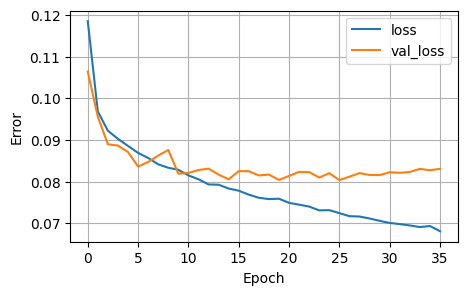

In [85]:
plot_loss(history)

Clear example of overfitting

In [87]:
model.evaluate(X_scaled, y, verbose=0)

0.06811845302581787

In [88]:
min(history.history["val_loss"])

0.08034538477659225

In [89]:
y_pred = model.predict(X_test).ravel()

test_mae  = mean_absolute_error(y_test, y_pred)
test_rmse =  np.sqrt(mean_squared_error(y_test, y_pred))
test_r2   = r2_score(y_test, y_pred)

print("Test MAE :", test_mae)
print("Test RMSE:", test_rmse)
print("Test R2  :", test_r2)

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Test MAE : 0.0671884012038808
Test RMSE: 0.08761904431463284
Test R2  : 0.8431877599558097


In [94]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_scores  = []
rmse_scores = []
r2_scores   = []

for train_idx, test_idx in kf.split(X_scaled):
    X_tr, X_te = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]  

    model = build_compile_model()  
    model.fit(X_tr, y_tr, epochs=100, verbose=0)

    y_pred = model.predict(X_te).ravel()

    mae_scores.append(mean_absolute_error(y_te, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_te, y_pred)))
    r2_scores.append(r2_score(y_te, y_pred))

print("CV MAE :", np.mean(mae_scores),  np.std(mae_scores))
print("CV RMSE:", np.mean(rmse_scores), np.std(rmse_scores))
print("CV R2  :", np.mean(r2_scores),   np.std(r2_scores))


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
CV MAE : 0.08566220852015147 0.0010990815958998538
CV RMSE: 0.10876221766968083 0.0012766715591146479
CV R2  : 0.759262810564594 0.010433838665220583


# BEST RESULT

The best result was from the XGBoost model.

In [116]:
study.best_value

0.07221110145815698

Xgboost model best Parameters:

'n_estimators': 1677,

 'learning_rate': 0.015410651054383025,

 'max_depth': 7,

 'min_child_weight': 19.4994159530713,

 'subsample': 0.8,
 
 'colsample_bytree': 0.8

## Scores:

XGB Test MAE:  0.0722

XGB Test R2:   0.8255

XGB Test RMSE: 0.0924


## Cross validated scores: 

CV MAE 0.07461695102488301

CV R2 0.8198282631372766

CV RMSE 0.09411708415800128

In [117]:
permutation_importance_cv(best_xgb, X, y, n_splits=5)

,importance_mean,importance_std_across_folds,perm_std_mean
EV_diff,0.069118,0.001545,0.001633
La,0.014622,0.000340,0.000737
Regret_B,0.011827,0.000315,0.000527
Amb,0.011095,0.000705,0.000582
Regret_A,0.009603,0.000529,0.000475
EW_diff,0.008879,0.000790,0.000492
Ha,0.007836,0.000595,0.000427
Lb,0.005728,0.000221,0.000496
Hb,0.005353,0.000369,0.000438
pHb,0.004700,0.000479,0.000384


The most important feature for predicting the choice frequency of Gamble B is the difference in expected value between the two options (EV_diff). When Gamble B has a higher expected value than Gamble A, people are more likely to choose B, and this effect is strong and consistent across all problems. However, expected value alone does not fully explain behavior. The results show that people are also influenced by the sizes of the possible outcomes themselves (Ha, La, Hb, Lb), meaning that large gains or losses affect choices even when they do not substantially change expected value.

Anticipated regret is another key factor. The features Regret_A and Regret_B indicate that people tend to avoid options that could make them feel worse if the alternative turns out much better. In particular, higher potential regret from choosing B reduces the probability of choosing B, while higher regret from choosing A increases it. Ambiguity (Amb) is also important: when the probabilities of outcomes are not clearly known, people are less likely to choose the ambiguous option, even if its expected value is favorable.

Equal-weight valuation (EW_diff) has a smaller but meaningful effect. This shows that people sometimes simplify decisions by roughly averaging outcomes instead of fully accounting for probabilities. Probability-related features (pHa, pHb) do matter, but their influence is weaker than that of outcome magnitudes and regret, suggesting that probabilities are used imperfectly. Features related to dominance (A_dominates, B_dominates) and worst-case outcomes (Worst_diff) have lower overall importance, indicating that they affect decisions mainly in specific edge cases where one option is clearly better or much riskier.

These behaviours are of course better explained by the papers, but it is very telling that the best result from these models incorporates in a way every one of these human behavioural tendecies. 